# Assignment 1 Debug

In [10]:
# import
import sys

import matplotlib.pyplot as plt
from tqdm import tqdm

sys.path.append("..")

from utils.data import get_dataloaders


In [11]:
# data loading
mnist = get_dataloaders("mnist", batch_size=64, data_root="../data")
cifar10 = get_dataloaders("cifar10", batch_size=64, data_root="../data")
cifar10_preprocess = get_dataloaders(
    "cifar10",
    batch_size=64,
    data_root="../data",
    use_preprocess=True,
)

for dataset in tqdm([mnist, cifar10, cifar10_preprocess], desc="datasets"):
    images, labels = next(iter(dataset["train_loader"]))
    print(dataset["dataset_name"], "preprocess" if dataset["use_preprocess"] else "")
    print("data root:", dataset["data_root"])
    print("classes:", dataset["num_classes"])
    print("input shape:", dataset["input_shape"])
    print("image batch:", tuple(images.shape))
    print("label batch:", tuple(labels.shape))
    print()


/home/ahy0502/anaconda3/envs/trustworthy-ai-a1/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
datasets: 100%|██████████| 3/3 [00:00<00:00, 23.39it/s]

mnist 
data root: ../data/mnist
classes: 10
input shape: (1, 28, 28)
image batch: (64, 1, 28, 28)
label batch: (64,)

cifar10 
data root: ../data/cifar10
classes: 10
input shape: (3, 32, 32)
image batch: (64, 3, 32, 32)
label batch: (64,)

cifar10 preprocess
data root: ../data/cifar10
classes: 10
input shape: (3, 224, 224)
image batch: (64, 3, 224, 224)
label batch: (64,)



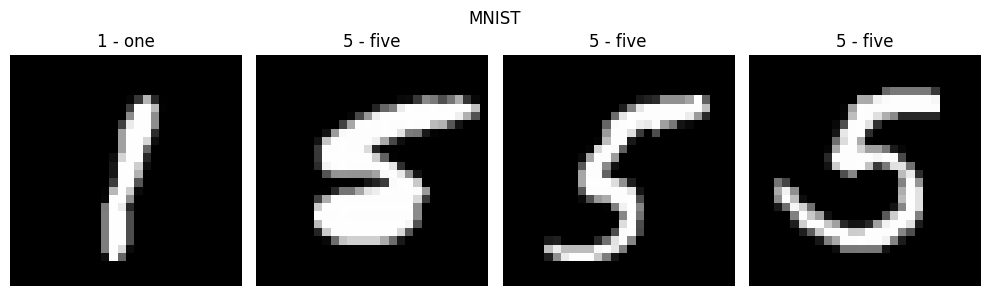

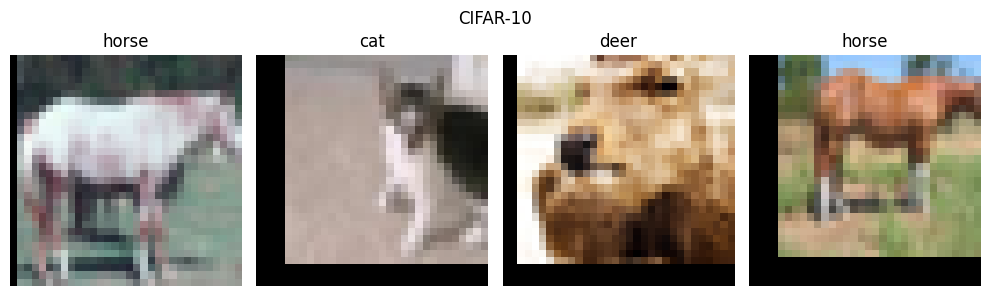

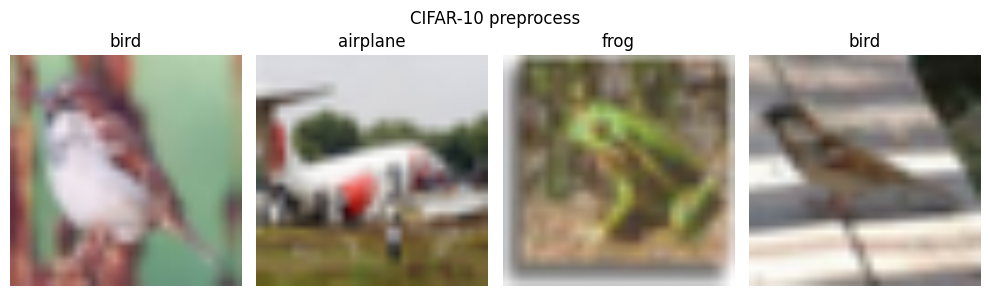

In [12]:
# data visualize
def show_batch(dataset, title):
    images, labels = next(iter(dataset["train_loader"]))
    images = images[:8]
    labels = labels[:8]

    fig, axes = plt.subplots(1, 4, figsize=(10, 3))
    axes = axes.flatten()

    for ax, image, label in zip(axes, images, labels):
        if image.shape[0] == 1:
            ax.imshow(image.squeeze(0), cmap="gray")
        else:
            ax.imshow(image.permute(1, 2, 0))
        ax.set_title(dataset["class_names"][int(label)])
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_batch(mnist, "MNIST")
show_batch(cifar10, "CIFAR-10")
show_batch(cifar10_preprocess, "CIFAR-10 preprocess")


In [13]:
# MNIST model
from models.mnist_cnn import MNISTCNN

mnist_model = MNISTCNN(
    use_dropout=False,
    use_bn=False,
    use_gelu=False,
    use_softmax=False,
)

mnist_images, mnist_labels = next(iter(mnist["train_loader"]))
mnist_logits = mnist_model(mnist_images)

print(mnist_model)
print("input batch:", tuple(mnist_images.shape))
print("output batch:", tuple(mnist_logits.shape))


MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Identity()
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Identity()
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): Identity()
    (3): ReLU(inplace=True)
    (4): Identity()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
  (out): Identity()
)
input batch: (64, 1, 28, 28)
output batch: (64, 10)


In [14]:
# MNIST training / accuracy
import torch

from utils.train import train_classifier

mnist_device = torch.device(
    "cuda:4"
    if torch.cuda.is_available() and torch.cuda.device_count() > 4
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
mnist_epochs = 3
mnist_lr = 1e-3

mnist_model, mnist_history = train_classifier(
    mnist_model,
    mnist["train_loader"],
    mnist["test_loader"],
    device=mnist_device,
    epochs=mnist_epochs,
    lr=mnist_lr,
)

print("device:", mnist_device)
print("final train loss:", f"{mnist_history['train_loss'][-1]:.4f}")
print("final train acc:", f"{mnist_history['train_acc'][-1]:.4f}")
print("final clean test acc:", f"{mnist_history['test_acc'][-1]:.4f}")


eval 1/3: 100%|██████████| 157/157 [00:00<00:00, 222.04it/s, acc=0.9835]


epoch 1: train_loss=0.1654, train_acc=0.9498, test_acc=0.9835


eval 2/3: 100%|██████████| 157/157 [00:00<00:00, 215.01it/s, acc=0.9872]


epoch 2: train_loss=0.0491, train_acc=0.9852, test_acc=0.9872


eval 3/3: 100%|██████████| 157/157 [00:00<00:00, 250.42it/s, acc=0.9899]

epoch 3: train_loss=0.0344, train_acc=0.9892, test_acc=0.9899
device: cuda:4
final train loss: 0.0344
final train acc: 0.9892
final clean test acc: 0.9899


In [15]:
# CIFAR-10 model
from models.cifar_resnet import CIFARResNet

use_pretrained = False
use_gelu = False
use_softmax = False

dataset = cifar10_preprocess if use_pretrained else cifar10

model = CIFARResNet(
    use_pretrained=use_pretrained,
    use_gelu=use_gelu,
    use_softmax=use_softmax,
)

images, labels = next(iter(dataset["train_loader"]))
logits = model(images)

print(model)
print("use_pretrained:", use_pretrained)
print("dataset:", "cifar10_preprocess" if use_pretrained else "cifar10")
print("input batch:", tuple(images.shape))
print("output batch:", tuple(logits.shape))


CIFARResNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
       

In [16]:
# CIFAR-10 training / accuracy
import torch

from utils.train import train_classifier

model = model
dataset = dataset
device = torch.device(
    "cuda:4"
    if torch.cuda.is_available() and torch.cuda.device_count() > 4
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

if use_pretrained:
    epochs = 3
    lr = 1e-4
else:
    epochs = 10
    lr = 1e-3

model, history = train_classifier(
    model,
    dataset["train_loader"],
    dataset["test_loader"],
    device=device,
    epochs=epochs,
    lr=lr,
)

print("device:", device)
print("epochs:", epochs)
print("lr:", lr)
print("final train loss:", f"{history['train_loss'][-1]:.4f}")
print("final train acc:", f"{history['train_acc'][-1]:.4f}")
print("final clean test acc:", f"{history['test_acc'][-1]:.4f}")


train 1/10:   0%|          | 0/782 [00:00<?, ?it/s]

eval 1/10: 100%|██████████| 157/157 [00:00<00:00, 170.12it/s, acc=0.6304]


epoch 1: train_loss=1.3410, train_acc=0.5113, test_acc=0.6304


eval 2/10: 100%|██████████| 157/157 [00:01<00:00, 152.24it/s, acc=0.7361]


epoch 2: train_loss=0.8685, train_acc=0.6902, test_acc=0.7361


...

epoch 8: train_loss=0.3635, train_acc=0.8751, test_acc=0.8298


eval 9/10: 100%|██████████| 157/157 [00:01<00:00, 130.73it/s, acc=0.8613]


epoch 9: train_loss=0.3312, train_acc=0.8877, test_acc=0.8613


eval 10/10: 100%|██████████| 157/157 [00:01<00:00, 134.89it/s, acc=0.8795]

epoch 10: train_loss=0.3002, train_acc=0.8965, test_acc=0.8795
device: cuda:4
epochs: 10
lr: 0.001
final train loss: 0.3002
final train acc: 0.8965
final clean test acc: 0.8795
